In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [5]:
from sklearn.datasets import fetch_openml
import pandas as pd

data = fetch_openml(data_id=41554, as_frame=True)

df = data.frame

df.head()

,Xloc,Yloc,Landuse_1,Landuse_2,Landuse_3,Landuse_4,Rock_1,Rock_2,Rock_3,Rock_4,Rock_5,Cr,Ni,Pb,Zn,Cd,Co,Cu
0,2.386,3.077,0,0,1,0,0,0,1,0,0,38.32,21.32,77.36,92.56,1.740,9.32,25.72
1,2.544,1.972,0,1,0,0,0,1,0,0,0,40.20,29.72,77.88,73.56,1.335,10.00,24.76
2,2.807,3.347,0,1,0,0,0,0,1,0,0,47.00,21.40,30.80,64.80,1.610,10.60,8.88
3,4.308,1.933,0,0,1,0,0,1,0,0,0,43.52,29.72,56.40,90.00,2.150,11.92,22.70
4,4.383,1.081,0,0,1,0,0,0,0,0,1,38.52,26.20,66.40,88.40,1.565,16.32,34.32


In [6]:
print(df.head())

    Xloc   Yloc  Landuse_1  Landuse_2  Landuse_3  Landuse_4  Rock_1  Rock_2  \
0  2.386  3.077          0          0          1          0       0       0   
1  2.544  1.972          0          1          0          0       0       1   
2  2.807  3.347          0          1          0          0       0       0   
3  4.308  1.933          0          0          1          0       0       1   
4  4.383  1.081          0          0          1          0       0       0   

   Rock_3  Rock_4  Rock_5     Cr     Ni     Pb     Zn     Cd     Co     Cu  
0       1       0       0  38.32  21.32  77.36  92.56  1.740   9.32  25.72  
1       0       0       0  40.20  29.72  77.88  73.56  1.335  10.00  24.76  
2       1       0       0  47.00  21.40  30.80  64.80  1.610  10.60   8.88  
3       0       0       0  43.52  29.72  56.40  90.00  2.150  11.92  22.70  
4       0       0       1  38.52  26.20  66.40  88.40  1.565  16.32  34.32  


In [7]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359 entries, 0 to 358
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Xloc       359 non-null    float64
 1   Yloc       359 non-null    float64
 2   Landuse_1  359 non-null    int64  
 3   Landuse_2  359 non-null    int64  
 4   Landuse_3  359 non-null    int64  
 5   Landuse_4  359 non-null    int64  
 6   Rock_1     359 non-null    int64  
 7   Rock_2     359 non-null    int64  
 8   Rock_3     359 non-null    int64  
 9   Rock_4     359 non-null    int64  
 10  Rock_5     359 non-null    int64  
 11  Cr         359 non-null    float64
 12  Ni         359 non-null    float64
 13  Pb         359 non-null    float64
 14  Zn         359 non-null    float64
 15  Cd         359 non-null    float64
 16  Co         359 non-null    float64
 17  Cu         359 non-null    float64
dtypes: float64(9), int64(9)
memory usage: 50.6 KB
None


In [8]:
print(df.describe())

             Xloc        Yloc   Landuse_1   Landuse_2   Landuse_3   Landuse_4  \
count  359.000000  359.000000  359.000000  359.000000  359.000000  359.000000   
mean     2.963384    2.631769    0.142061    0.228412    0.607242    0.022284   
std      0.980822    1.269089    0.349600    0.420396    0.489045    0.147812   
min      0.491000    0.524000    0.000000    0.000000    0.000000    0.000000   
25%      2.260500    1.510500    0.000000    0.000000    0.000000    0.000000   
50%      3.040000    2.489000    0.000000    0.000000    1.000000    0.000000   
75%      3.674000    3.652000    0.000000    0.000000    1.000000    0.000000   
max      4.920000    5.690000    1.000000    1.000000    1.000000    1.000000   

           Rock_1      Rock_2      Rock_3      Rock_4      Rock_5          Cr  \
count  359.000000  359.000000  359.000000  359.000000  359.000000  359.000000   
mean     0.211699    0.345404    0.247911    0.016713    0.178273   35.017827   
std      0.409083    0.4761

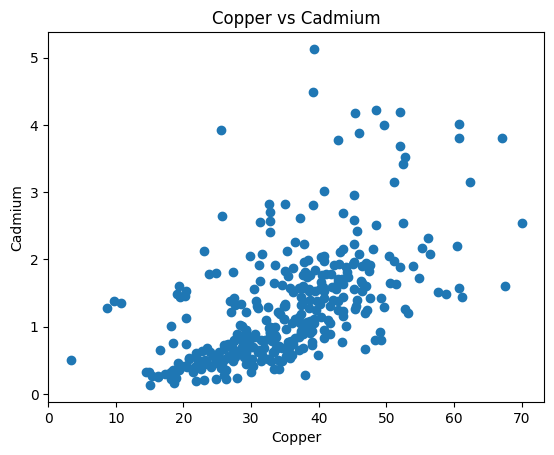

In [11]:
import matplotlib.pyplot as plt
plt.scatter(df['Cr'], df['Cd'])
plt.title("Copper vs Cadmium")
plt.xlabel("Copper")
plt.ylabel("Cadmium")
plt.show()

In [12]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['xloc', 'yloc', 'landuse_1', 'landuse_2', 'landuse_3', 'landuse_4',
       'rock_1', 'rock_2', 'rock_3', 'rock_4', 'rock_5', 'cr', 'ni', 'pb',
       'zn', 'cd', 'co', 'cu'],
      dtype='object')


In [14]:
X = df.drop('cd', axis=1)
y = df['cd']

##Polynomial Features

In [15]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
print("Polynomial features created ✅")

Polynomial features created ✅


##Standard Scaling

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
print("Feature scaling done ✅")

Feature scaling done ✅


##Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Data split done ✅")

Data split done ✅


##Train Multiple Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression trained ✅")

Linear Regression trained ✅


##Train Ridge Regression

In [19]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
print("Ridge Regression trained ✅")

Ridge Regression trained ✅


##Train Lasso Regression

In [20]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
print("Lasso Regression trained ✅")

Lasso Regression trained ✅


##Predictions

In [21]:
y_pred_lr = lr_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

##RMSE and R² Score

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)


In [23]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)


In [24]:
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)


In [25]:
print("Linear Regression → RMSE:", rmse_lr, "R2:", r2_lr)
print("Ridge Regression → RMSE:", rmse_ridge, "R2:", r2_ridge)
print("Lasso Regression → RMSE:", rmse_lasso, "R2:", r2_lasso)

Linear Regression → RMSE: 0.8328470808943296 R2: -0.06897541552737452
Ridge Regression → RMSE: 0.5436805249582448 R2: 0.5444618700451495
Lasso Regression → RMSE: 0.8087172166439488 R2: -0.007930435176925155


##Observe Coefficients

In [26]:
print("Linear Coefficients:\n", lr_model.coef_)
print("Ridge Coefficients:\n", ridge_model.coef_)
print("Lasso Coefficients:\n", lasso_model.coef_)

Linear Coefficients:
 [-1.52636106e-01  4.35489373e-01  4.17901890e-02 -6.66587332e-02
  1.05519664e-02  5.58329578e-02  8.56176263e-02  5.69267814e-02
 -6.57678219e-02 -8.22630949e-03 -8.51524800e-02  8.86594978e-01
 -6.25355180e-01 -5.36648895e-01 -2.86524139e-01  2.88164528e-01
  3.81827806e-01 -1.16107267e-01  8.79875674e-02  2.75238893e-01
 -2.45799755e-01 -1.04820650e-01  2.14590718e-02 -2.28898257e-01
  1.27735788e-01  4.49287726e-02  6.22322894e-02 -1.57998299e-01
 -2.29803299e-01 -7.99946738e-01 -7.98999718e-01  1.96001005e+00
  5.32211123e-01 -2.75045908e-01 -2.25703242e-01 -4.22650387e-03
  2.17299432e-01  1.09882955e-01  2.77746390e-01  9.48857911e-03
  2.15910942e-01  2.55054165e-02 -9.88379853e-03  1.85739321e-01
 -6.56017301e-01  8.67833029e-01  5.52332928e-01 -4.14582694e-01
 -7.47936820e-01 -3.38991789e-02  4.17901890e-02 -2.04697370e-15
  2.49800181e-15  1.27675648e-15  2.77796239e-02  7.69157662e-03
  6.75088490e-02 -3.30806015e-03 -8.88178420e-16 -1.23014582e-01
 -4

##Features Reduced to Zero

In [27]:
import numpy as np
zero_features = np.where(lasso_model.coef_ == 0)[0]
print("Features reduced to zero (Lasso):", zero_features)

Features reduced to zero (Lasso): [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169]


##Feature Names for clarity

In [28]:
feature_names = poly.get_feature_names_out()
for i in zero_features:
    print(feature_names[i])

xloc
yloc
landuse_1
landuse_2
landuse_3
landuse_4
rock_1
rock_2
rock_3
rock_4
rock_5
cr
ni
pb
zn
co
cu
xloc^2
xloc yloc
xloc landuse_1
xloc landuse_2
xloc landuse_3
xloc landuse_4
xloc rock_1
xloc rock_2
xloc rock_3
xloc rock_4
xloc rock_5
xloc cr
xloc ni
xloc pb
xloc zn
xloc co
xloc cu
yloc^2
yloc landuse_1
yloc landuse_2
yloc landuse_3
yloc landuse_4
yloc rock_1
yloc rock_2
yloc rock_3
yloc rock_4
yloc rock_5
yloc cr
yloc ni
yloc pb
yloc zn
yloc co
yloc cu
landuse_1^2
landuse_1 landuse_2
landuse_1 landuse_3
landuse_1 landuse_4
landuse_1 rock_1
landuse_1 rock_2
landuse_1 rock_3
landuse_1 rock_4
landuse_1 rock_5
landuse_1 cr
landuse_1 ni
landuse_1 pb
landuse_1 zn
landuse_1 co
landuse_1 cu
landuse_2^2
landuse_2 landuse_3
landuse_2 landuse_4
landuse_2 rock_1
landuse_2 rock_2
landuse_2 rock_3
landuse_2 rock_4
landuse_2 rock_5
landuse_2 cr
landuse_2 ni
landuse_2 pb
landuse_2 zn
landuse_2 co
landuse_2 cu
landuse_3^2
landuse_3 landuse_4
landuse_3 rock_1
landuse_3 rock_2
landuse_3 rock_3
land